# Alpha=26 deconvolution profiles

Now that the CLOCCS parameters are correct and the two replicates are producing concordante deconvolution results. We now look at the daughter specific genes, DSE1-4 to determine the alpha value that is required, per Xin:

"We calibrated the duration of the attachment period to be the smallest duration such that the decon- volved transcription profiles of all four genes are primarily within DG1"


In [15]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from src.model import Model
from src.config import load_yl_replicate1_rg1_alpha_vst_config
config1 = load_yl_replicate1_rg1_alpha_vst_config()


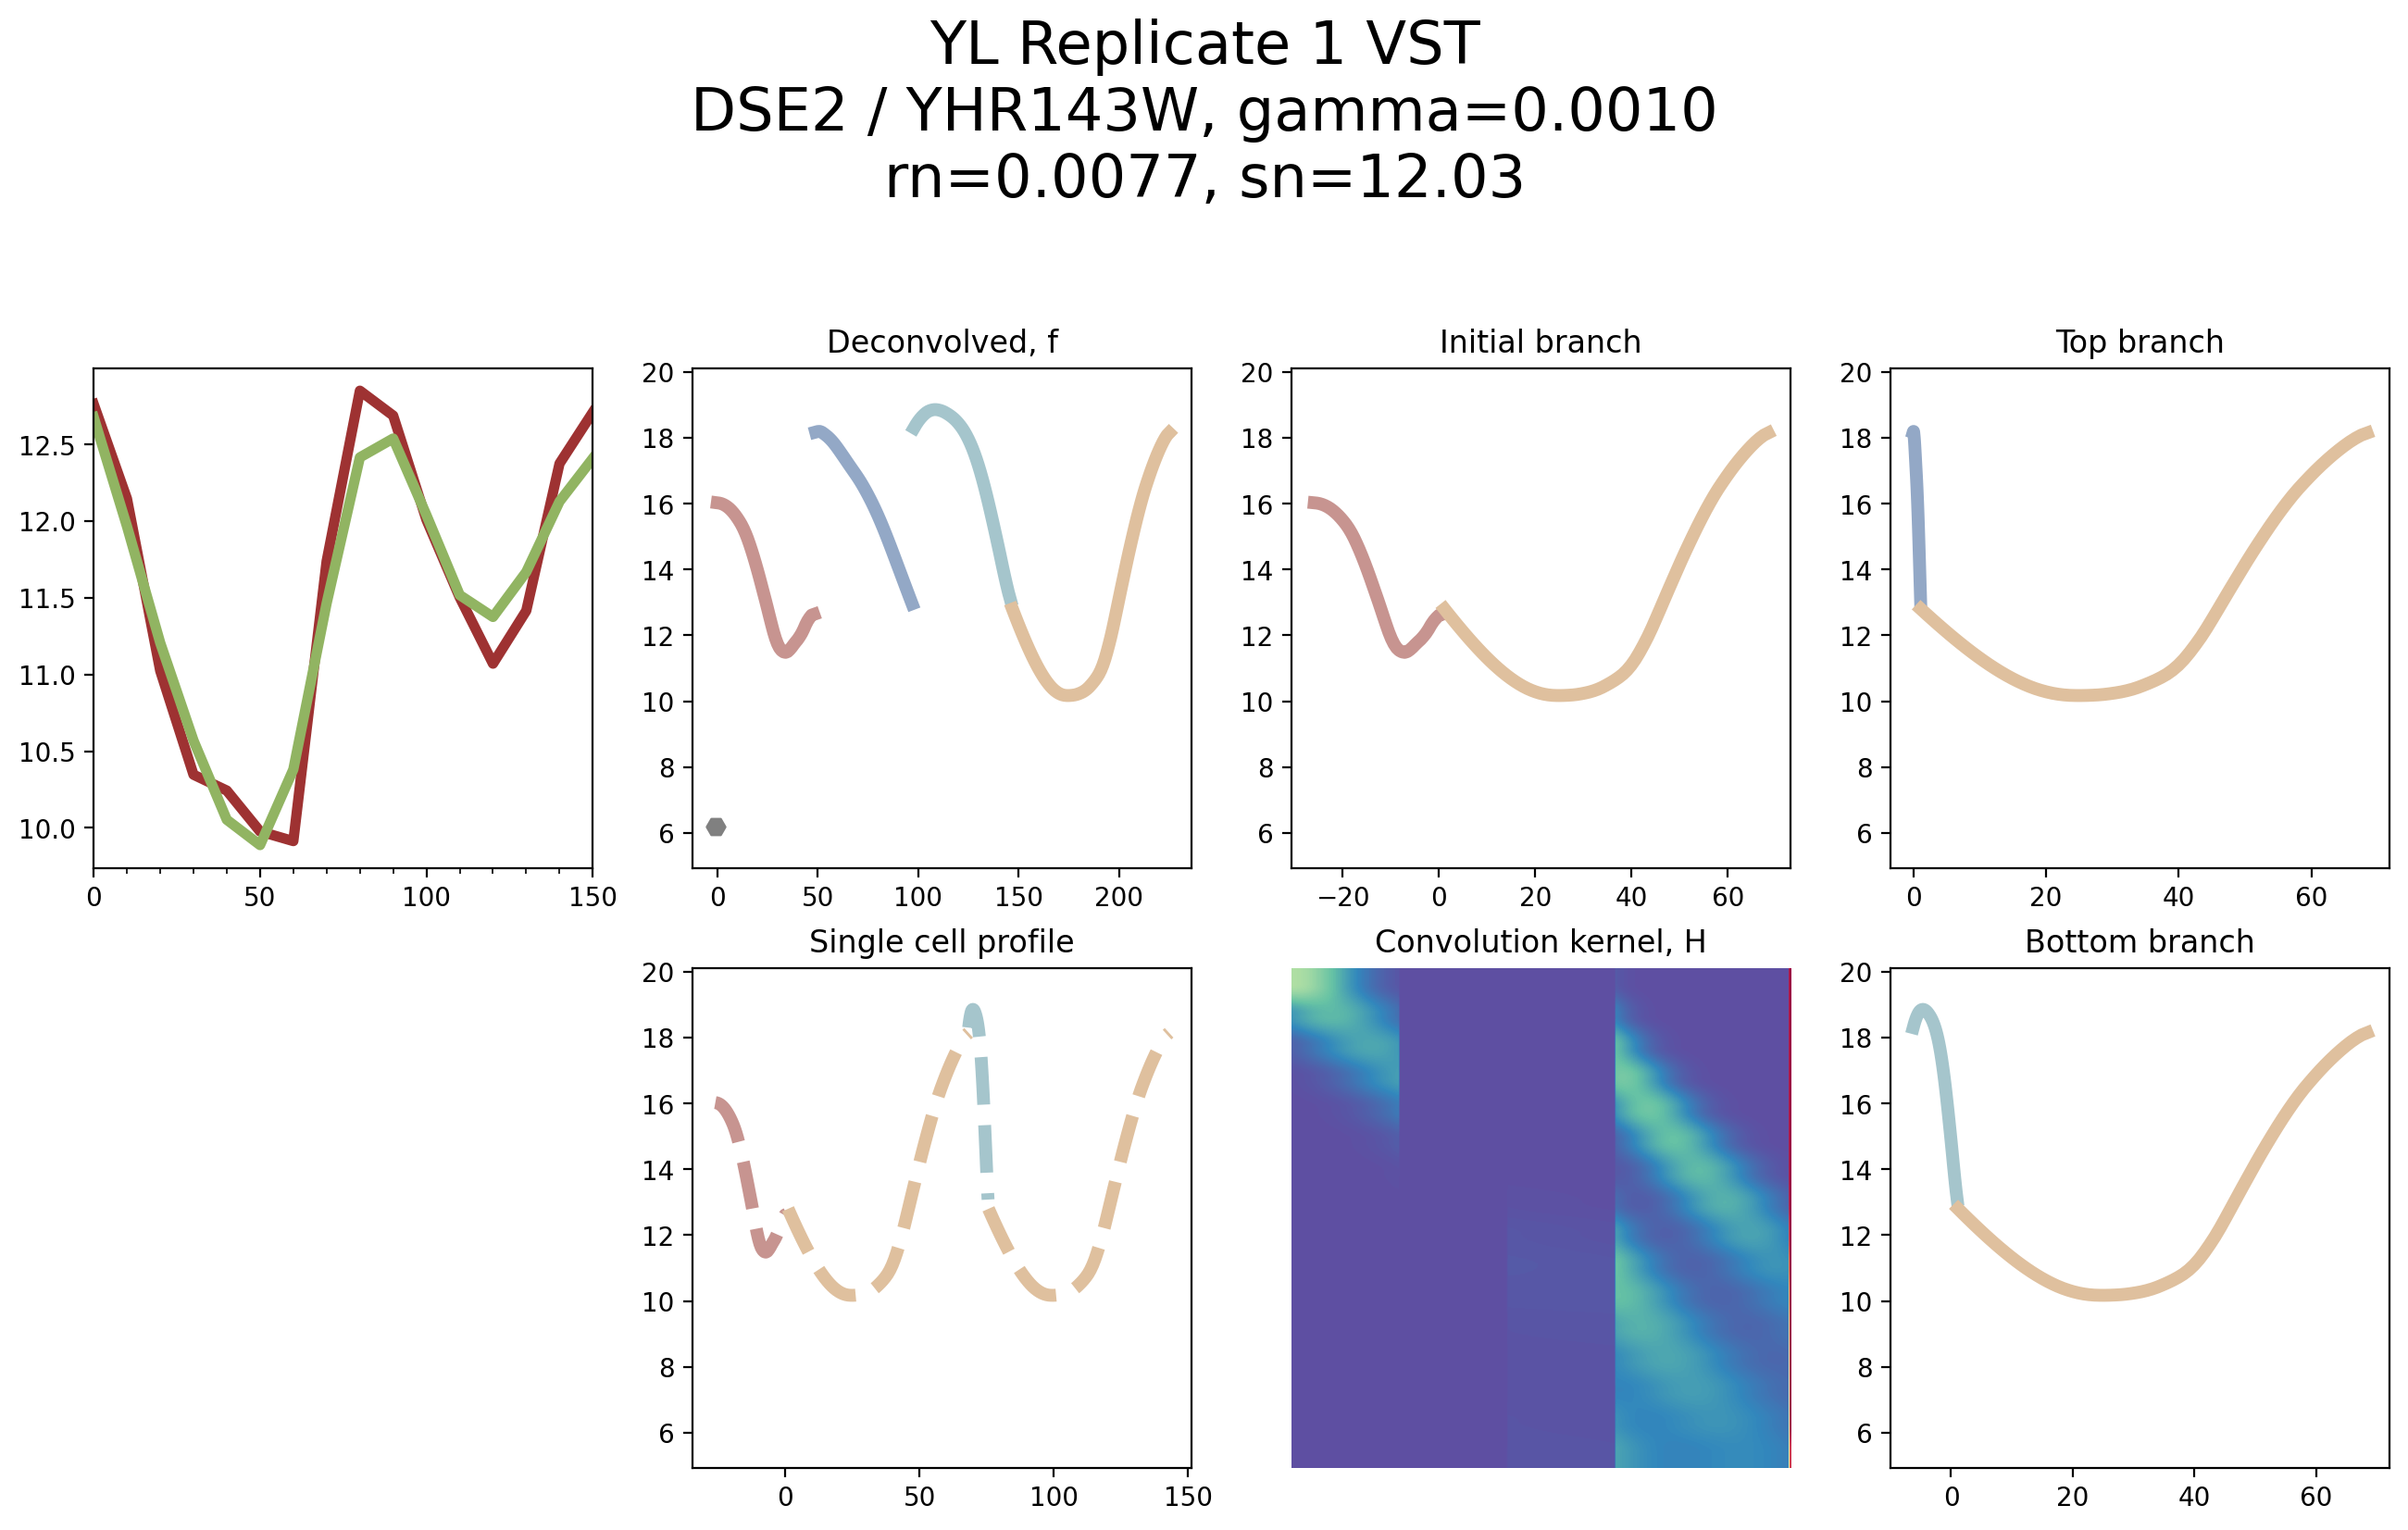

In [19]:
gene_name = "DSE2"
model1 = Model(config1, gene_name, 0.0007)
model1.deconvolve_find_optimal_gamma()
model1.plot_deconvolved_gene()

In [60]:
def compute_prop_in_dg1(model1):
    config = model1.config
    
    dg1_indices = config.get_timepoints_phases_Hpositions_for_branch('b')[0][2]
    postg1_indices = config.get_timepoints_phases_Hpositions_for_branch('b')[1][2]

    cg1_indices = config.get_timepoints_phases_Hpositions_for_branch('t')[0][2]
    rg1_indices = config.get_timepoints_phases_Hpositions_for_branch('i')[0][2]

    f = model1.f

    dg1_f = f[dg1_indices]
    cg1_f = f[cg1_indices]
    rg1_f = f[rg1_indices]
    postg1_f = f[postg1_indices]

    return dg1_f.sum() / f.sum()

In [62]:
from src.dynamic_config_alpha import create_dynamic_alpha_config

gene_name = "DSE2"
dg1_props = []

for alpha in np.arange(0, 60, 10):
    posteriors_filepath = 'data/yl_2019_replicate1/posteriors.txt'
    config = create_dynamic_alpha_config(posteriors_filepath, alpha, 1, 
        f"Replicate 1, alpha={alpha}")

    model1 = Model(config, gene_name, 0.0007)
    #model1.deconvolve_find_optimal_gamma()
    model1.deconvolve()
    #model1.plot_deconvolved_gene()
    
    dg1_prop = compute_prop_in_dg1(model1)
    dg1_props.append(dg1_prop)

    print(f"For alpha={alpha}, DG1 proportion={dg1_prop*100:.2f}%")

For alpha=0, DG1 proportion=25.90%
For alpha=10, DG1 proportion=28.20%
For alpha=20, DG1 proportion=30.53%
For alpha=30, DG1 proportion=28.45%
For alpha=40, DG1 proportion=26.22%
For alpha=50, DG1 proportion=22.95%
